# Challenge 03: Inteligencia Geo-Temporal y de Redes

**TechLogistics S.A.** | Maestría en Ciencia de Datos - EAFIT | Periodo 2026-1

TechLogistics tiene dos redes de sensores georreferenciadas pero desconectadas entre sí — una
agroindustrial y una eléctrica — y necesita tres cosas para tomar decisiones: saber **dónde**
están los problemas (geoespacial), entender **cómo se propagan** las fallas (grafos), y **qué
tan confiable** es lo que se puede pronosticar (series de tiempo). Este notebook resuelve esas
tres preguntas en 4 fases, siguiendo la metodología CRISP-DM.

## Índice

| Fase | Contenido | Preguntas que responde |
|---|---|---|
| **Fase 1** — Data Understanding y Geo-Visualización | Tarea 1: mapa de sensores agro (NDVI/Humedad) · Tarea 2: estacionariedad de las series de energía | ¿Dónde hay zonas de biomasa baja? ¿Qué series se pueden correlacionar/modelar directamente? |
| **Fase 2** — Procesamiento de Señales y Filtrado | Tarea 3: análisis espectral de la Generación Eólica · Tarea 4: filtrado de la Humedad Relativa | ¿En qué frecuencias está el ruido? ¿Vale la pena filtrar antes de predecir? |
| **Fase 3** — Análisis de Grafos y Topología de Red | Tarea 5: construcción de la red de sensores/subestaciones y sus centralidades | ¿Qué nodo es el cuello de botella de la red? |
| **Fase 4** — Modelado y Toma de Decisiones | P1: causalidad y riesgo de red · P2: inversión hídrica · P3: pronóstico de demanda | ¿Dónde invertir? ¿Qué tan expuesta está la red a una falla? ¿Se puede pronosticar la demanda? |

**Integrantes del equipo:**

| Nombre completo |
| --- |
| Samuel Gutiérrez Jaramillo |
| David Lopera Londoño |
| Juan Diego Acuña Giraldo |


## Fase 1: Data Understanding y Geo-Visualización

**TechLogistics S.A.** | Maestría en Ciencia de Datos - EAFIT | Periodo 2026-1

Esta fase cubre las dos tareas asignadas dentro del Challenge 03:

1. **Tarea 1 — Exploración Geo-Temporal:** visualización espacial de la red de
   sensores agroindustriales (`agro_clean.csv`) codificando NDVI y Humedad.
2. **Tarea 2 — Análisis de Estacionariedad y Windowing:** diagnóstico ADF sobre
   las series de energía (`ener_clean.csv`), con ventana móvil para las series
   no estacionarias y análisis de Drift vs. Random Walk en `Ener_5`.


In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
from statsmodels.tsa.stattools import adfuller, kpss

pd.set_option('display.max_columns', None)


### Tarea 1: Exploración Geo-Temporal

Cargamos `agro_clean.csv`. Cada fila representa una lectura de un sensor
agroindustrial en el Oriente Antioqueño, georreferenciada con `Latitude` y
`Longitude`, y conectada a un `Target_Node` (gateway) dentro de la red mesh.


In [3]:
agro = pd.read_csv('../data/raw/agro_clean.csv')
print(agro.shape)
agro.head()


(2000, 14)


,Agro_1,Agro_2,Agro_3,Agro_4,Agro_5,Agro_6,Agro_7,Agro_8,Agro_9,Agro_10,Latitude,Longitude,Source_Node,Target_Node
0,60.248357,47.797447,65.395554,0.000000,0.478718,2.498349,10.000000,6.432151,1.258741,4.663639,6.203680,-75.400366,4,17
1,60.080940,48.076702,66.143237,25.002075,0.467100,2.473166,10.006672,6.469450,1.106051,4.683748,6.282310,-75.474525,14,21
2,60.623974,48.002378,66.342755,49.941596,0.449259,2.464547,10.013349,6.440262,1.183610,8.353141,6.165190,-75.476937,14,22
3,61.211672,48.267738,66.826015,74.756163,0.439299,2.500284,10.020030,6.511042,1.197917,6.213966,6.131334,-75.468152,8,25
4,60.483063,47.912028,65.703353,99.383693,0.436016,2.564177,10.026716,6.619718,1.200795,8.720976,6.241746,-75.349805,5,26


#### Estructura del DataFrame

Antes de meternos en el análisis, miramos con `info()` la estructura de `agro_clean.csv`: tipos de
columna y valores no nulos.

In [4]:
agro.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Agro_1       2000 non-null   float64
 1   Agro_2       2000 non-null   float64
 2   Agro_3       2000 non-null   float64
 3   Agro_4       2000 non-null   float64
 4   Agro_5       2000 non-null   float64
 5   Agro_6       2000 non-null   float64
 6   Agro_7       2000 non-null   float64
 7   Agro_8       2000 non-null   float64
 8   Agro_9       2000 non-null   float64
 9   Agro_10      2000 non-null   float64
 10  Latitude     2000 non-null   float64
 11  Longitude    2000 non-null   float64
 12  Source_Node  2000 non-null   int64  
 13  Target_Node  2000 non-null   int64  
dtypes: float64(12), int64(2)
memory usage: 218.9 KB


#### Perfilamiento rápido

Antes de visualizar, confirmamos que no hay nulos ni duplicados evidentes
(según el enunciado, esta versión `clean` no debería tenerlos).


In [5]:
print("Nulos por columna:")
print(agro.isna().sum())
print("\nFilas duplicadas:", agro.duplicated().sum())
print("\nSensores únicos (Source_Node):", agro['Source_Node'].nunique())
print("Gateways únicos (Target_Node):", agro['Target_Node'].nunique())


Nulos por columna:
Agro_1         0
Agro_2         0
Agro_3         0
Agro_4         0
Agro_5         0
Agro_6         0
Agro_7         0
Agro_8         0
Agro_9         0
Agro_10        0
Latitude       0
Longitude      0
Source_Node    0
Target_Node    0
dtype: int64

Filas duplicadas: 0

Sensores únicos (Source_Node): 14
Gateways únicos (Target_Node): 15


#### Mapa geoespacial: color = NDVI (Agro_5), tamaño = Humedad (Agro_1)

Usamos `scatter_mapbox` de Plotly Express. Como cada sensor tiene múltiples
lecturas en el tiempo, primero agregamos por `Source_Node` (promedio de NDVI
y Humedad, y su ubicación) para tener **un punto por sensor** en el mapa —
graficar cada lectura individual saturaría el mapa sin aportar señal espacial
adicional.


In [6]:
agro_geo = (
    agro.groupby('Source_Node')
    .agg(
        Latitude=('Latitude', 'mean'),
        Longitude=('Longitude', 'mean'),
        NDVI=('Agro_5', 'mean'),
        Humedad=('Agro_1', 'mean'),
        Target_Node=('Target_Node', lambda x: x.mode()[0]),
    )
    .reset_index()
)
agro_geo.head()


,Source_Node,Latitude,Longitude,NDVI,Humedad,Target_Node
0,1,6.201189,-75.400394,1.134482,61.303896,17
1,2,6.201115,-75.395744,1.158621,61.185142,16
2,3,6.198764,-75.404026,1.200254,60.859097,20
3,4,6.201792,-75.394481,1.185135,60.961797,19
4,5,6.202941,-75.402092,1.117531,60.846702,19


#### Mapa interactivo con Plotly

Construimos el mapa con `scatter_mapbox` usando los promedios por sensor: el color de cada punto es
el NDVI (`Agro_5`) y el tamaño la humedad (`Agro_1`).

In [7]:
fig = px.scatter_mapbox(
    agro_geo,
    lat='Latitude',
    lon='Longitude',
    color='NDVI',
    size='Humedad',
    hover_name='Source_Node',
    hover_data={'Target_Node': True, 'NDVI': ':.3f', 'Humedad': ':.2f'},
    color_continuous_scale='RdYlGn',
    size_max=25,
    zoom=9,
    height=600,
    title='Red de Sensores Agroindustriales — Color: NDVI | Tamaño: Humedad',
)
fig.update_layout(mapbox_style='open-street-map')
fig.update_layout(margin={'r': 0, 't': 40, 'l': 0, 'b': 0})
fig.write_html('../results/figuras/mapa_agro_ndvi_humedad.html', auto_open=False)
fig.show()


C:\Users\user\AppData\Local\Temp\ipykernel_22952\3566232451.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


#### Análisis: ¿hay clustering espacial de biomasa baja?

Para responder de forma objetiva (no solo visual), calculamos el umbral del
cuartil inferior de NDVI y revisamos si los sensores por debajo de ese umbral
se concentran geográficamente (distancia promedio entre ellos vs. distancia
promedio general).


In [8]:
q1_ndvi = agro_geo['NDVI'].quantile(0.25)
bajo_ndvi = agro_geo[agro_geo['NDVI'] <= q1_ndvi].copy()
print(f"Umbral Q1 de NDVI: {q1_ndvi:.3f}")
print(f"Sensores con NDVI bajo (<= Q1): {len(bajo_ndvi)} de {len(agro_geo)}")
bajo_ndvi[['Source_Node', 'Latitude', 'Longitude', 'NDVI', 'Humedad']].sort_values('NDVI')


Umbral Q1 de NDVI: 1.137
Sensores con NDVI bajo (<= Q1): 4 de 14


,Source_Node,Latitude,Longitude,NDVI,Humedad
13,14,6.205431,-75.404362,1.105670,61.389763
9,10,6.200163,-75.392642,1.117056,60.312579
4,5,6.202941,-75.402092,1.117531,60.846702
0,1,6.201189,-75.400394,1.134482,61.303896


**Nota metodológica:** usar distancia euclidiana directa sobre grados de
latitud/longitud es incorrecto — un grado de longitud no equivale a la misma
distancia real que un grado de latitud (la equivalencia depende del coseno de
la latitud), y con pocos puntos ese sesgo puede voltear la conclusión.
Usamos la fórmula de **Haversine** para obtener distancias reales en metros
sobre la superficie terrestre.


In [9]:
from itertools import combinations

def haversine(p1, p2):
    """Distancia en metros entre dos puntos (lat, lon) sobre la Tierra."""
    lat1, lon1 = p1
    lat2, lon2 = p2
    R = 6371000  # radio terrestre en metros
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


#### Inspección por pares: ¿todos los sensores de NDVI bajo están agrupados, o solo algunos?

Un promedio agregado de distancias sobre el grupo completo no es una métrica
útil aquí: con solo 4 puntos, un único sensor alejado infla el promedio y
puede ocultar que el resto sí esté agrupado. Por eso miramos directamente la
matriz de distancias par a par entre los sensores de NDVI bajo.


In [10]:
nodos_bajo = list(zip(bajo_ndvi['Source_Node'], zip(bajo_ndvi['Latitude'], bajo_ndvi['Longitude'])))

print(f"{'Nodo A':>8} {'Nodo B':>8} {'Distancia (m)':>15}")
pares = []
for (n1, c1), (n2, c2) in combinations(nodos_bajo, 2):
    d = haversine(c1, c2)
    pares.append((n1, n2, d))
    print(f"{n1:>8} {n2:>8} {d:>15.1f}")

pares_df = pd.DataFrame(pares, columns=['Nodo_A', 'Nodo_B', 'Distancia_m']).sort_values('Distancia_m')
pares_df


  Nodo A   Nodo B   Distancia (m)
       1        5           270.6
       1       10           864.5
       1       14           644.1
       5       10          1089.4
       5       14           373.6
      10       14          1421.8


,Nodo_A,Nodo_B,Distancia_m
0,1,5,270.589413
4,5,14,373.590916
2,1,14,644.105813
1,1,10,864.453923
3,5,10,1089.383127
5,10,14,1421.780978


**Conclusión Tarea 1:** la matriz de distancias por pares confirma un
**clúster compacto entre los nodos 14, 5 y 1** (distancias de ~270 a ~644 m
entre ellos), mientras que el **nodo 10 es un outlier aislado** respecto a
ese grupo (~865-1,420 m de distancia).

**Interpretación de negocio:** la zona donde se ubican los nodos 14, 5 y 1 es
la candidata prioritaria para inversión en infraestructura hídrica (pregunta
de negocio P2 de la Fase 4) — ahí sí hay un patrón geográfico de biomasa
baja, no solo fallas puntuales de sensor. El nodo 10 debe tratarse por
separado: su NDVI bajo parece ser un caso aislado, posiblemente ligado a una
condición local del sensor/cultivo más que a la zona.


### Tarea 2: Análisis de Estacionariedad y Windowing

Cargamos `ener_clean.csv`. El diccionario de datos etiqueta explícitamente:
- `Ener_5-7` (Costo de Gas, Emisiones CO2, etc.): **No Estacionarias**.
- `Ener_8-10` (Frecuencia, Voltaje, Factor de Potencia): **Estacionarias**.

Para `Ener_1-3` (Demanda, Precio, Temperatura) el diccionario solo indica que
tienen correlación alta entre sí, sin pronunciarse sobre estacionariedad —
por eso el ADF/KPSS sobre esas tres variables es exploratorio, no una
verificación de algo ya anunciado.

El test ADF nos permite confirmar empíricamente las expectativas del
diccionario y, de paso, diagnosticar lo que no estaba anunciado.


In [11]:
ener = pd.read_csv('../data/raw/ener_clean.csv')
print(ener.shape)
ener.head()


(2000, 14)


,Ener_1,Ener_2,Ener_3,Ener_4,Ener_5,Ener_6,Ener_7,Ener_8,Ener_9,Ener_10,Latitude,Longitude,Source_Node,Target_Node
0,117.538413,169.976747,31.052273,40.000000,5.035559,999.997980,500.382001,60.007129,109.525783,0.952104,6.772983,-75.450170,106,244
1,123.085137,178.287791,30.367913,40.001201,4.964209,1000.012288,499.156777,60.010171,109.396517,0.963803,6.817829,-76.987525,113,241
2,122.444639,178.064846,29.483741,40.004804,4.885030,1000.185140,499.276252,59.998643,110.560808,0.939290,5.519644,-73.757957,105,233
3,117.595897,175.257364,29.985873,40.010804,5.039720,1000.075905,499.093300,59.994357,109.234773,0.945306,8.788327,-73.611230,105,237
4,123.471177,186.082293,30.359202,40.019198,5.046006,999.714688,499.380771,59.955593,110.202660,0.951658,8.450681,-73.456254,108,206


#### Estructura del dataset de energía

Al igual que con el agro, revisamos la estructura de `ener_clean.csv` con `info()` para confirmar
tipos y ausencia de nulos.

In [12]:
ener.info()
print("\nNulos por columna:")
print(ener.isna().sum())
print("\nFilas duplicadas:", ener.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ener_1       2000 non-null   float64
 1   Ener_2       2000 non-null   float64
 2   Ener_3       2000 non-null   float64
 3   Ener_4       2000 non-null   float64
 4   Ener_5       2000 non-null   float64
 5   Ener_6       2000 non-null   float64
 6   Ener_7       2000 non-null   float64
 7   Ener_8       2000 non-null   float64
 8   Ener_9       2000 non-null   float64
 9   Ener_10      2000 non-null   float64
 10  Latitude     2000 non-null   float64
 11  Longitude    2000 non-null   float64
 12  Source_Node  2000 non-null   int64  
 13  Target_Node  2000 non-null   int64  
dtypes: float64(12), int64(2)
memory usage: 218.9 KB

Nulos por columna:
Ener_1         0
Ener_2         0
Ener_3         0
Ener_4         0
Ener_5         0
Ener_6         0
Ener_7         0
Ener_8         0
Ener_9         0
Ener_1

#### Test ADF sobre todas las series `Ener_1` a `Ener_10`

- **H0:** la serie tiene raíz unitaria → no estacionaria.
- **H1:** la serie es estacionaria.
- Regla: si `p-value < 0.05` → rechazamos H0 → **estacionaria (I(0))**.

Complementamos con **KPSS** (hipótesis nula invertida: H0 = estacionaria) para
tener un diagnóstico cruzado más robusto, especialmente en los casos donde
ADF dé un resultado ambiguo.


In [13]:
def diagnostico_estacionariedad(serie, nombre):
    adf_stat, adf_p, *_ = adfuller(serie.dropna(), autolag='AIC')

    # KPSS puede lanzar warning de interpolación en los p-values extremos; lo ignoramos aquí
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, *_ = kpss(serie.dropna(), regression='c', nlags='auto')

    adf_concl = 'Estacionaria' if adf_p < 0.05 else 'No Estacionaria'
    kpss_concl = 'No Estacionaria' if kpss_p < 0.05 else 'Estacionaria'

    return {
        'Variable': nombre,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_conclusion': adf_concl,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_conclusion': kpss_concl,
        'Coinciden': adf_concl == kpss_concl,
    }

cols_ener = [f'Ener_{i}' for i in range(1, 11)]
resultados = [diagnostico_estacionariedad(ener[c], c) for c in cols_ener]
df_estacionariedad = pd.DataFrame(resultados)
df_estacionariedad


,Variable,ADF_stat,ADF_p,ADF_conclusion,KPSS_stat,KPSS_p,KPSS_conclusion,Coinciden
0,Ener_1,-1.866900e+00,0.3478,No Estacionaria,0.3836,0.0842,Estacionaria,False
1,Ener_2,-1.479100e+00,0.5438,No Estacionaria,0.3701,0.0900,Estacionaria,False
2,Ener_3,-1.928400e+00,0.3188,No Estacionaria,0.3735,0.0886,Estacionaria,False
3,Ener_4,-8.418193e+09,0.0000,Estacionaria,0.0684,0.1000,Estacionaria,True
4,Ener_5,-3.477000e-01,0.9185,No Estacionaria,6.9235,0.0100,No Estacionaria,True
5,Ener_6,9.527000e-01,0.9937,No Estacionaria,6.9870,0.0100,No Estacionaria,True
6,Ener_7,-4.244000e-01,0.9059,No Estacionaria,7.0007,0.0100,No Estacionaria,True
7,Ener_8,-4.603630e+01,0.0000,Estacionaria,0.0489,0.1000,Estacionaria,True
8,Ener_9,-4.535820e+01,0.0000,Estacionaria,0.0438,0.1000,Estacionaria,True
9,Ener_10,-4.371510e+01,0.0000,Estacionaria,0.1114,0.1000,Estacionaria,True


In [14]:
# Ener_4 dio un ADF_stat = -1.34e+10 en la tabla anterior — no es un valor válido.
# Diagnóstico: probamos distintos maxlag fijos para ver si el problema es el lag elegido por AIC
# o algo más estructural de la serie.
for maxlag_fijo in (1, 2, 3, 5, 8, 10):
    stat, p, usedlag, *_ = adfuller(ener['Ener_4'].dropna(), maxlag=maxlag_fijo, autolag='AIC')
    print(f'maxlag={maxlag_fijo:>2d} -> usedlag={usedlag:>2d}  stat={stat:>15.4g}  p={p:.4g}')

maxlag= 1 -> usedlag= 1  stat=         -203.6  p=0
maxlag= 2 -> usedlag= 2  stat=         -2.402  p=0.1412
maxlag= 3 -> usedlag= 3  stat=     -1.265e+08  p=0
maxlag= 5 -> usedlag= 5  stat=     -9.275e+08  p=0
maxlag= 8 -> usedlag= 8  stat=     -3.702e+09  p=0
maxlag=10 -> usedlag=10  stat=     -8.418e+09  p=0


**Nota metodológica — ADF no confiable para `Ener_4`:**

Ningún lag da un ADF numéricamente sano para esta serie: con lag=1 el estadístico ya es
anormalmente grande (-203.6), con lag=2 se vuelve ambiguo (p=0.14, ya no rechaza raíz
unitaria), y de lag=3 en adelante degenera a valores de miles de millones. No es un tema de
elegir mejor el lag: `Ener_4` es una serie casi determinística (Tarea 3 ya mostró que ~100% de
su potencia está por debajo de 0.05 ciclos/muestra, prácticamente sin ruido), lo que vuelve casi
singular la regresión del test ADF sin importar cuántos rezagos se usen.

**Decisión:** para `Ener_4` no usamos el ADF como evidencia. Nos apoyamos en el KPSS
(p=0.10, no rechaza estacionariedad) y en la evidencia espectral independiente de la Tarea 3
(energía concentrada en banda bajísima, sin comportamiento de raíz unitaria) para sostener la
clasificación de `Ener_4` como Estacionaria. Marcamos esto explícitamente en la tabla exportada
para que quede trazable en el CSV de resultados, no solo en el texto del notebook.

El resto de las variables no se toca: sus ADF son numéricamente sanos y ya están verificados.

#### Exportar el diagnóstico

Guardamos el resultado del test ADF/KPSS en `results/diagnostico_estacionariedad_ener.csv` y
dejamos listas las series no estacionarias, que son las que vamos a diferenciar más adelante.

In [15]:
df_estacionariedad['ADF_confiable'] = df_estacionariedad['Variable'] != 'Ener_4'
df_estacionariedad.loc[df_estacionariedad['Variable'] == 'Ener_4', 'ADF_conclusion'] = 'No confiable (ver nota) - Estacionaria por KPSS + espectro'

df_estacionariedad.to_csv('../results/diagnostico_estacionariedad_ener.csv', index=False)
no_estacionarias = df_estacionariedad[df_estacionariedad['ADF_conclusion'] == 'No Estacionaria']['Variable'].tolist()
print("Series clasificadas como NO estacionarias (ADF):", no_estacionarias)
df_estacionariedad

Series clasificadas como NO estacionarias (ADF): ['Ener_1', 'Ener_2', 'Ener_3', 'Ener_5', 'Ener_6', 'Ener_7']


,Variable,ADF_stat,ADF_p,ADF_conclusion,KPSS_stat,KPSS_p,KPSS_conclusion,Coinciden,ADF_confiable
0,Ener_1,-1.866900e+00,0.3478,No Estacionaria,0.3836,0.0842,Estacionaria,False,True
1,Ener_2,-1.479100e+00,0.5438,No Estacionaria,0.3701,0.0900,Estacionaria,False,True
2,Ener_3,-1.928400e+00,0.3188,No Estacionaria,0.3735,0.0886,Estacionaria,False,True
3,Ener_4,-8.418193e+09,0.0000,No confiable (ver nota) - Estacionaria por KPS...,0.0684,0.1000,Estacionaria,True,False
4,Ener_5,-3.477000e-01,0.9185,No Estacionaria,6.9235,0.0100,No Estacionaria,True,True
5,Ener_6,9.527000e-01,0.9937,No Estacionaria,6.9870,0.0100,No Estacionaria,True,True
6,Ener_7,-4.244000e-01,0.9059,No Estacionaria,7.0007,0.0100,No Estacionaria,True,True
7,Ener_8,-4.603630e+01,0.0000,Estacionaria,0.0489,0.1000,Estacionaria,True,True
8,Ener_9,-4.535820e+01,0.0000,Estacionaria,0.0438,0.1000,Estacionaria,True,True
9,Ener_10,-4.371510e+01,0.0000,Estacionaria,0.1114,0.1000,Estacionaria,True,True


**Conclusión Tarea 2:** con la coincidencia o no entre ADF y KPSS como
criterio, y la pendiente de la media móvil de `Ener_5` confirmando un
comportamiento de Drift, esta es la clasificación final:

**Clasificación final adoptada:**
- **No Estacionarias (evidencia sólida, ADF y KPSS coinciden):** `Ener_5`,
  `Ener_6`, `Ener_7`.
- **No Estacionarias (caso ambiguo, tratadas como tal por precaución):**
  `Ener_1`, `Ener_2`, `Ener_3`.
- **Estacionarias (evidencia sólida, ADF y KPSS coinciden):** `Ener_8`,
  `Ener_9`, `Ener_10`.
- **Estacionaria (ADF no confiable numéricamente; evidencia por KPSS +
  espectro de la Tarea 3):** `Ener_4`. Ver nota metodológica arriba.

Esta clasificación es la que se debe usar consistentemente en las Fases 2-4
del taller (diferenciación previa a Pearson/ARIMA, selección de variables
para el modelo ARIMAX, etc.).

#### Ventana móvil (50 registros) para las series no estacionarias

Para cada serie no estacionaria calculamos media y varianza móvil con
ventana de 50 registros. Graficarlas todas juntas en la misma escala es
engañoso: `Ener_6` y `Ener_7` tienen rangos de cientos de unidades mientras
`Ener_1-3` se mueven en decenas, así que estas últimas se verían "planas"
por escala, no porque carezcan de tendencia. Por eso usamos subplots
independientes, cada uno con su propio eje.


In [16]:
from plotly.subplots import make_subplots

fig_rolling = make_subplots(
    rows=2, cols=3,
    subplot_titles=no_estacionarias,
)
posiciones = [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3)]

for (col, (row, colpos)) in zip(no_estacionarias, posiciones):
    roll_mean = ener[col].rolling(window=50).mean()
    fig_rolling.add_scatter(
        x=ener.index, y=roll_mean, name=col, row=row, col=colpos, showlegend=False,
    )

fig_rolling.update_layout(height=600, title_text='Media Móvil (ventana=50) — Escala independiente por variable')
fig_rolling.write_html('../results/figuras/media_movil_no_estacionarias.html', auto_open=False)
fig_rolling.show()


#### Métrica objetiva de fuerza de tendencia

Para no depender de una lectura visual, calculamos, por cada serie no
estacionaria: el **rango de su media móvil** (máximo - mínimo) dividido entre
la **desviación estándar de la serie completa**. Un ratio alto indica que la
media móvil se desplaza más de lo que varía el ruido normal de la serie
→ tendencia dominante. Un ratio bajo indica que la media móvil apenas se
mueve en comparación con el ruido propio de la serie → comportamiento más
cercano a estacionario alrededor de una tendencia débil.


In [17]:
fuerza_tendencia = []
for col in no_estacionarias:
    roll_mean = ener[col].rolling(window=50).mean().dropna()
    rango_media_movil = roll_mean.max() - roll_mean.min()
    std_serie = ener[col].std()
    ratio = rango_media_movil / std_serie
    fuerza_tendencia.append({'Variable': col, 'Rango_media_movil': round(rango_media_movil, 3),
                              'Std_serie': round(std_serie, 3), 'Ratio_tendencia_ruido': round(ratio, 3)})

df_fuerza = pd.DataFrame(fuerza_tendencia).sort_values('Ratio_tendencia_ruido', ascending=False)
df_fuerza


,Variable,Rango_media_movil,Std_serie,Ratio_tendencia_ruido
5,Ener_7,39.141,11.585,3.379
4,Ener_6,192.276,57.405,3.349
3,Ener_5,20.956,6.474,3.237
0,Ener_1,40.427,14.440,2.800
2,Ener_3,10.116,3.615,2.799
1,Ener_2,61.197,21.898,2.795


**Nota:** el ratio tendencia/ruido resultó similar en orden de magnitud
para las seis series (~2.8 a ~3.4), así que no se usa como criterio de
decisión — la clasificación se basa en la coincidencia o no entre ADF y
KPSS, como se estableció antes.


#### Decisión de tratamiento: casos ambiguos

**Marcamos `Ener_1`, `Ener_2` y `Ener_3` como CASOS AMBIGUOS**: ADF y KPSS se
contradicen (`Coinciden = False`), a diferencia de `Ener_5-7` donde ambos
tests coinciden en "No Estacionaria". El ratio tendencia/ruido no ayuda a
desambiguar (resultó similar en las seis series), así que la decisión se basa
únicamente en el patrón de acuerdo/desacuerdo entre ADF y KPSS.

**Decisión adoptada:** por precaución metodológica, tratamos los casos
ambiguos como **No Estacionarias** para todo el análisis posterior
(diferenciación antes de correlación de Pearson, ventana móvil, y cualquier
modelo tipo ARIMA/ARIMAX en fases siguientes). La razón es asimétrica: si una
serie ambigua en realidad es estacionaria y la tratamos como no estacionaria,
en el peor caso perdemos un poco de información al diferenciar de más; pero
si es realmente no estacionaria y la tratamos como estacionaria, el riesgo es
una correlación espuria o un modelo mal especificado — un error más grave
para las conclusiones de negocio. Esta es la postura que se debe citar en el
Informe Técnico al responder la pregunta de validación #1 del checklist.


In [18]:
fig_var = px.line(title='Varianza Móvil (ventana=50) — Series No Estacionarias')
for col in no_estacionarias:
    roll_var = ener[col].rolling(window=50).var()
    fig_var.add_scatter(x=ener.index, y=roll_var, name=f'{col} (varianza móvil)')
fig_var.update_layout(height=500, xaxis_title='Índice temporal', yaxis_title='Varianza')
fig_var.write_html('../results/figuras/varianza_movil_no_estacionarias.html', auto_open=False)
fig_var.show()


#### Ener_5 (Costo del Gas): ¿Drift o Random Walk?

- **Drift:** la media móvil crece (o decrece) de forma sostenida y consistente
  en una dirección — hay una tendencia determinística subyacente.
- **Random Walk puro:** la media móvil fluctúa sin una dirección clara, el
  valor de hoy es simplemente el de ayer más un shock aleatorio, sin sesgo
  direccional sistemático.


In [19]:
fig_gas = px.line(
    x=ener.index, y=ener['Ener_5'],
    title='Ener_5 (Costo del Gas) — Serie original',
    labels={'x': 'Índice temporal', 'y': 'Ener_5'},
)
roll_mean_gas = ener['Ener_5'].rolling(window=50).mean()
fig_gas.add_scatter(x=ener.index, y=roll_mean_gas, name='Media móvil (50)', line=dict(color='red', width=3))
fig_gas.update_layout(height=500)
fig_gas.write_html('../results/figuras/ener5_drift_vs_randomwalk.html', auto_open=False)
fig_gas.show()


#### ¿Drift o random walk? la evidencia numérica

Además de ver la gráfica, medimos la pendiente de la media móvil con una regresión lineal simple: si
la media móvil sube de forma sostenida, hablamos de drift y no de un paseo aleatorio.

In [20]:
# Pendiente de la tendencia (regresión lineal simple sobre la media móvil, sin NaN iniciales)
serie_valida = roll_mean_gas.dropna()
x = np.arange(len(serie_valida))
pendiente, intercepto = np.polyfit(x, serie_valida.values, 1)
print(f"Pendiente de la media móvil de Ener_5: {pendiente:.6f}")

if abs(pendiente) > 1e-3:
    print("→ La media móvil muestra una tendencia direccional sostenida: comportamiento consistente con DRIFT.")
else:
    print("→ La media móvil no muestra tendencia direccional clara: comportamiento consistente con RANDOM WALK puro.")


Pendiente de la media móvil de Ener_5: 0.011128
→ La media móvil muestra una tendencia direccional sostenida: comportamiento consistente con DRIFT.


**Conclusión Tarea 2:** con la coincidencia o no entre ADF y KPSS como
criterio, y la pendiente de la media móvil de `Ener_5` confirmando un
comportamiento de Drift, esta es la clasificación final:

**Clasificación final adoptada:**
- **No Estacionarias (evidencia sólida, ADF y KPSS coinciden):** `Ener_5`,
  `Ener_6`, `Ener_7`.
- **No Estacionarias (caso ambiguo, tratadas como tal por precaución):**
  `Ener_1`, `Ener_2`, `Ener_3`.
- **Estacionarias (evidencia sólida, ADF y KPSS coinciden):** `Ener_4`,
  `Ener_8`, `Ener_9`, `Ener_10`.

Esta clasificación es la que se debe usar consistentemente en las Fases 2-4
del taller (diferenciación previa a Pearson/ARIMA, selección de variables
para el modelo ARIMAX, etc.).


## Fase 2: Procesamiento de Señales y Filtrado

**TechLogistics S.A.** | Maestría en Ciencia de Datos — EAFIT | Periodo 2026-1

La Fase 1 nos dijo *qué* series se pueden correlacionar o modelar directamente y cuáles necesitan
diferenciarse. Esta fase resuelve un problema distinto: **¿los datos que llegan de los sensores
son confiables, o el ruido de la telemetría está distorsionando lo que medimos?** Trabajamos con
dos casos: la Generación Eólica (`Ener_4`), para entender en qué parte de la señal vive el ruido,
y la Humedad Relativa (`Agro_3`), para probar si limpiarla realmente mejora la capacidad de
predecir con esos datos.

### Tarea 3: Análisis Espectral (FFT) y Espectrogramas

**Pregunta de negocio:** ¿el ruido de telemetría de la Generación Eólica se puede separar de la
señal real, o está mezclado de forma que cualquier filtro también borraría información útil?
Para responder, no basta con mirar la serie en el tiempo — hay que ver **en qué frecuencias**
vive cada cosa. Un evento lento y suave (como el patrón diario del viento) se ve en frecuencias
bajas; un ruido errático se reparte en frecuencias altas. Separarlos en ese dominio es lo que
permite luego diseñar un filtro que se quede con lo útil y descarte lo demás.

In [21]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import signal

ener_clean = pd.read_csv('../data/raw/ener_clean.csv')
ener_noise = pd.read_csv('../data/raw/ener_noise.csv')

print('ener_clean:', ener_clean.shape)
print('ener_noise:', ener_noise.shape)

e4_clean = ener_clean['Ener_4'].values
e4_noise = ener_noise['Ener_4'].values

ener_clean: (2000, 14)
ener_noise: (2000, 14)


#### Cómo convertimos las lecturas en frecuencias

Los CSV no traen columna de tiempo explícita, así que asumimos que cada fila es una lectura
tomada a intervalos iguales (una "muestra por unidad de tiempo"). Esa suposición es necesaria
para poder hablar de "frecuencias" en absoluto: sin ella no hay forma de saber si un patrón se
repite cada 10 lecturas o cada 100.

Para estimar cómo se reparte la energía de la señal entre frecuencias usamos el método de Welch
(un promedio de varias ventanas), que da una estimación más estable que aplicar la transformada
de Fourier de una sola vez sobre toda la serie.

In [22]:
def snr_db(clean, noisy):
    ruido = noisy - clean
    return 10 * np.log10(np.var(clean) / np.var(ruido))

snr_e4 = snr_db(e4_clean, e4_noise)
print(f'SNR empírico de Ener_4: {snr_e4:.2f} dB')
print('¿Dentro del rango esperado [5, 12] dB?', 5 <= snr_e4 <= 12)

SNR empírico de Ener_4: 8.53 dB
¿Dentro del rango esperado [5, 12] dB? True


#### Comparando la versión limpia contra la ruidosa

Graficamos la distribución de energía por frecuencia de `Ener_4` en sus dos versiones (`clean` y
`noise`). Si el ruido inyectado ocupa una zona distinta a la señal real, debería verse como un
"piso" adicional de energía que la versión limpia no tiene.

In [23]:
fs = 1.0
f_c, psd_c = signal.welch(e4_clean, fs=fs, nperseg=256)
f_n, psd_n = signal.welch(e4_noise, fs=fs, nperseg=256)

fig_psd = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        subplot_titles=['Ener_4 clean', 'Ener_4 noise'])
fig_psd.add_trace(go.Scatter(x=f_c, y=10 * np.log10(psd_c), name='clean',
                             line=dict(color='green')), row=1, col=1)
fig_psd.add_trace(go.Scatter(x=f_n, y=10 * np.log10(psd_n), name='noise',
                             line=dict(color='red')), row=2, col=1)
fig_psd.update_xaxes(title='Frecuencia (ciclos/muestra)', range=[0, 0.5], row=2, col=1)
fig_psd.update_yaxes(title='PSD (dB)')
fig_psd.update_layout(height=600, title='PSD de Ener_4 — clean vs noise (Welch, fs=1)')
fig_psd.write_html('../results/figuras/fase2_ener4_psd_clean_noise.html', auto_open=False)
fig_psd.show()

#### ¿El ruido es constante en el tiempo o aparece en ráfagas?

El análisis anterior promedia toda la serie en un solo resultado, así que no distingue si el
ruido está presente todo el tiempo o solo en ciertos tramos. Para verlo, dividimos la serie en
ventanas de tiempo cortas y calculamos el espectro de cada una por separado — así vemos cómo
cambia la composición de frecuencias a lo largo de la serie, no solo en promedio.

In [24]:
nperseg, noverlap = 256, 128
f_stft, t_stft, Sxx_c = signal.spectrogram(e4_clean, fs=fs, nperseg=nperseg,
                                           noverlap=noverlap, window='hann')

fig_spec_c = go.Figure(go.Heatmap(
    x=t_stft, y=f_stft, z=10 * np.log10(Sxx_c + 1e-12),
    colorscale='Viridis', colorbar=dict(title='dB')))
fig_spec_c.update_layout(title='Espectrograma Ener_4 — CLEAN',
                         xaxis_title='Tiempo (índice)',
                         yaxis_title='Frecuencia (ciclos/muestra)', height=500)
fig_spec_c.write_html('../results/figuras/fase2_ener4_espectrograma_clean.html', auto_open=False)
fig_spec_c.show()

Repetimos el mismo análisis por ventanas para la versión `noise` de `Ener_4`, usando
exactamente los mismos parámetros que en la versión `clean`, para poder comparar ambas
imágenes lado a lado sin que la diferencia sea un artefacto de la configuración.

In [25]:
f_stft, t_stft, Sxx_n = signal.spectrogram(e4_noise, fs=fs, nperseg=nperseg,
                                           noverlap=noverlap, window='hann')

fig_spec_n = go.Figure(go.Heatmap(
    x=t_stft, y=f_stft, z=10 * np.log10(Sxx_n + 1e-12),
    colorscale='Viridis', colorbar=dict(title='dB')))
fig_spec_n.update_layout(title='Espectrograma Ener_4 — NOISE',
                         xaxis_title='Tiempo (índice)',
                         yaxis_title='Frecuencia (ciclos/muestra)', height=500)
fig_spec_n.write_html('../results/figuras/fase2_ener4_espectrograma_noise.html', auto_open=False)
fig_spec_n.show()

#### Poniendo números a lo que se ve en la gráfica

Para no quedarnos solo con la lectura visual, calculamos qué porcentaje de la energía total cae
en cada rango de frecuencias, tanto en la versión limpia como en la ruidosa. Esto nos permite
decir con precisión dónde está la señal real y dónde está el ruido, en vez de una impresión
general.

In [26]:
def potencia_banda(f, psd, lo, hi):
    m = (f >= lo) & (f < hi)
    return 100 * psd[m].sum() / psd.sum()

bandas = [(0.0, 0.05), (0.05, 0.1), (0.1, 0.2), (0.2, 0.5)]
filas = []
for lo, hi in bandas:
    filas.append({
        'Banda (ciclos/muestra)': f'[{lo:.2f}, {hi:.2f})',
        'Potencia CLEAN (%)': round(potencia_banda(f_c, psd_c, lo, hi), 1),
        'Potencia NOISE (%)': round(potencia_banda(f_n, psd_n, lo, hi), 1),
    })
df_bandas = pd.DataFrame(filas)
df_bandas

,Banda (ciclos/muestra),Potencia CLEAN (%),Potencia NOISE (%)
0,"[0.00, 0.05)",100.0,86.0
1,"[0.05, 0.10)",0.0,1.4
2,"[0.10, 0.20)",0.0,3.2
3,"[0.20, 0.50)",0.0,9.4


#### Aislando el ruido inyectado

La versión `noise` es señal + ruido mezclados, así que en las frecuencias bajas todavía predomina
la señal real. Para ver el ruido "puro", restamos la versión limpia de la ruidosa
(`noise - clean`): lo que queda es, en teoría, solo lo que el ejercicio inyectó artificialmente.
Verificamos además que ese residuo se comporte como ruido genuino (sin patrón propio) revisando
su autocorrelación.

In [27]:
from statsmodels.tsa.stattools import acf

residual = e4_noise - e4_clean
f_r, psd_r = signal.welch(residual, fs=fs, nperseg=256)

filas_r = []
for lo, hi in bandas:
    filas_r.append({
        'Banda (ciclos/muestra)': f'[{lo:.2f}, {hi:.2f})',
        'Potencia del RUIDO inyectado (%)': round(potencia_banda(f_r, psd_r, lo, hi), 1),
    })
df_ruido = pd.DataFrame(filas_r)

acf1 = acf(residual, nlags=1)[1]
print(f'ACF(lag 1) del residual: {acf1:.3f}  →  "ruido blanco" si ~ 0')
df_ruido

ACF(lag 1) del residual: 0.010  →  "ruido blanco" si ~ 0


,Banda (ciclos/muestra),Potencia del RUIDO inyectado (%)
0,"[0.00, 0.05)",9.5
1,"[0.05, 0.10)",8.9
2,"[0.10, 0.20)",20.7
3,"[0.20, 0.50)",60.7


#### Respuesta Tarea 3 — ¿en qué frecuencias está el ruido?

**Para negocio:** la Generación Eólica real es una señal "lenta" — casi toda su variación
ocurre en un rango de frecuencias bajo, consistente con patrones de viento que cambian de forma
gradual. El ruido de telemetría, en cambio, es errático y está repartido en frecuencias altas,
donde la señal real prácticamente no tiene información. Eso es una buena noticia operativa:
**el ruido y la señal viven en zonas distintas**, así que sí se puede diseñar un filtro que
limpie los datos sin perder la información real del comportamiento eólico.

**Evidencia técnica:** la señal de `Ener_4` concentra ~100% de su energía por debajo de
0.05 ciclos/muestra. El ruido inyectado es ruido blanco de banda ancha (autocorrelación ≈ 0),
con más peso relativo en frecuencias altas (~21% en la banda [0.1, 0.2) y ~61% en [0.2, 0.5)),
justo donde la señal no aporta nada. El SNR estimado (~8.5 dB) cae dentro del rango [5, 12] dB
que anuncia el enunciado. Esto confirma que un filtro pasa-bajo con corte entre 0.1 y 0.2
ciclos/muestra debería limpiar el ruido sin sacrificar la señal real — lo que probamos en la
Tarea 4.

### Tarea 4: Filtrado y Reconstrucción

**Pregunta de negocio:** si limpiamos el ruido de un sensor, ¿el dato resultante realmente sirve
mejor para tomar decisiones (por ejemplo, para pronosticar), o el filtrado es solo un ejercicio
estético que no cambia nada en la práctica? Lo probamos sobre la Humedad Relativa (`Agro_3`), y
como la Tarea 3 ya nos dijo que el ruido vive en frecuencias altas, la herramienta natural es un
filtro que deje pasar las frecuencias bajas (donde está la señal real) y corte las altas.

In [28]:
agro_clean = pd.read_csv('../data/raw/agro_clean.csv')
agro_noise = pd.read_csv('../data/raw/agro_noise.csv')

agro3_clean = agro_clean['Agro_3'].values
agro3_noise = agro_noise['Agro_3'].values

snr_agro3 = snr_db(agro3_clean, agro3_noise)
print(f'SNR empírico de Agro_3: {snr_agro3:.2f} dB')
print('¿Dentro del rango esperado [5, 12] dB?', 5 <= snr_agro3 <= 12)

SNR empírico de Agro_3: 10.78 dB
¿Dentro del rango esperado [5, 12] dB? True


#### El filtro que usamos

Aplicamos un filtro Butterworth pasa-bajo — una técnica estándar que deja pasar sin distorsión
las frecuencias bajas y atenúa gradualmente las altas. Las decisiones de diseño, en términos
prácticos:

- **Qué tan agresivo es el filtro (orden 4):** un balance entre limpiar bien el ruido y no
  distorsionar la forma real de la señal. Un filtro demasiado agresivo puede "aplanar" eventos
  reales junto con el ruido.
- **Dónde cortamos (0.15 ciclos/muestra):** lo suficientemente alto para no comerse información
  real, y lo suficientemente bajo para dejar fuera la banda donde domina el ruido (Tarea 3).
- **Sin desfase temporal (`filtfilt`):** el filtro no desplaza la señal en el tiempo, algo
  importante porque estamos limpiando datos ya grabados, no filtrando en vivo.

In [29]:
orden, cutoff = 4, 0.15
b_bw, a_bw = signal.butter(orden, cutoff, btype='low', fs=fs)
agro3_filtrada = signal.filtfilt(b_bw, a_bw, agro3_noise)

print(f'Butterworth: orden={orden}, cutoff={cutoff} ciclos/muestra (fs=1, Nyquist=0.5)')
print(f'std(original)={agro3_clean.std():.2f} | std(ruidosa)={agro3_noise.std():.2f} | '
      f'std(filtrada)={agro3_filtrada.std():.2f}')


Butterworth: orden=4, cutoff=0.15 ciclos/muestra (fs=1, Nyquist=0.5)
std(original)=11.56 | std(ruidosa)=11.97 | std(filtrada)=11.61


Graficamos las tres versiones de `Agro_3` — original, con ruido, y filtrada — para ver
a simple vista si el filtro realmente recupera la forma de la señal real antes de medirlo con
números.

In [30]:
fig_rec = go.Figure()
fig_rec.add_trace(go.Scatter(y=agro3_clean, name='Agro_3 original (clean)',
                             line=dict(color='green', width=1)))
fig_rec.add_trace(go.Scatter(y=agro3_noise, name='Agro_3 ruidosa',
                             line=dict(color='gray', width=1, dash='dot')))
fig_rec.add_trace(go.Scatter(y=agro3_filtrada, name='Agro_3 filtrada (Butterworth)',
                             line=dict(color='red', width=2)))
fig_rec.update_layout(title='Reconstrucción de Agro_3 (Humedad Relativa) — original vs ruidosa vs filtrada',
                      xaxis_title='Índice temporal', yaxis_title='Agro_3',
                      height=500, legend=dict(orientation='h'))
fig_rec.write_html('../results/figuras/fase2_agro3_butterworth_reconstruccion.html', auto_open=False)
fig_rec.show()

#### ¿Qué tan cerca queda la versión filtrada de la realidad?

Medimos el error entre cada versión (ruidosa y filtrada) y la serie original limpia. Si el
filtrado funciona, el error de la versión filtrada debería ser claramente menor que el de la
versión ruidosa sin tocar.

In [31]:
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

rmse_ruidosa = rmse(agro3_clean, agro3_noise)
rmse_filtrada = rmse(agro3_clean, agro3_filtrada)

print(f'RMSE(original, ruidosa)  = {rmse_ruidosa:.4f}')
print(f'RMSE(original, filtrada) = {rmse_filtrada:.4f}')
print(f'Reducción del error de reconstrucción: {100 * (1 - rmse_filtrada / rmse_ruidosa):.1f}%')

RMSE(original, ruidosa)  = 3.3414
RMSE(original, filtrada) = 1.8491
Reducción del error de reconstrucción: 44.7%


#### La pregunta que realmente le importa al negocio: ¿mejora el pronóstico?

Que el filtro "se vea mejor" o tenga menos error de reconstrucción no garantiza que sirva para
lo que en la práctica se necesita: predecir. Para probarlo de forma honesta, entrenamos un
modelo de pronóstico simple con los primeros 1,500 registros y lo evaluamos prediciendo,
paso a paso, los últimos 500 — comparando qué tan bien predice cada versión de la serie (clean,
ruidosa, filtrada). Menor error de predicción = mejor insumo para decisiones futuras.

In [32]:
from statsmodels.tsa.ar_model import AutoReg

TRAIN = 1500

def one_step_rmse(serie, lag):
    modelo = AutoReg(serie[:TRAIN], lags=lag).fit()
    preds = np.empty(len(serie) - TRAIN)
    for i in range(TRAIN, len(serie) - 1):
        historial = np.concatenate([[1.0], serie[i - lag + 1:i + 1]])
        preds[i - TRAIN] = historial @ modelo.params
    obs = serie[TRAIN + 1:]
    return float(np.sqrt(np.mean((obs - preds[:len(obs)]) ** 2)))

filas_pred = []
for lag in (1, 2, 3):
    filas_pred.append({
        'Orden AR': lag,
        'RMSE clean': round(one_step_rmse(agro3_clean, lag), 4),
        'RMSE ruidosa': round(one_step_rmse(agro3_noise, lag), 4),
        'RMSE filtrada': round(one_step_rmse(agro3_filtrada, lag), 4),
    })
df_pred = pd.DataFrame(filas_pred)
df_pred

,Orden AR,RMSE clean,RMSE ruidosa,RMSE filtrada
0,1,1.0740,4.5273,0.8243
1,2,0.9289,3.9762,2.1477
2,3,0.8978,3.7299,2.4153


#### ¿El filtro también recupera la "receta" interna de la serie?

Además de qué tan bien predice, revisamos si los coeficientes internos del modelo (la forma en
que el valor de hoy depende de los de ayer) se parecen más a los de la serie original cuando
usamos la versión filtrada en vez de la ruidosa. Esto responde una pregunta más profunda: el
filtro no solo debe predecir mejor, idealmente también debería recuperar el comportamiento real
del proceso, no solo maquillar el ruido.

In [33]:
# Ajustamos un AR(2) sobre el mismo tramo de entrenamiento y comparamos los coeficientes lado a lado
ajustes = {}
for nombre, serie in [('clean', agro3_clean), ('noise', agro3_noise), ('filtrada', agro3_filtrada)]:
    ajustes[nombre] = np.asarray(AutoReg(serie[:TRAIN], lags=2).fit().params)

df_coefs = pd.DataFrame(ajustes, index=['const', 'AR_Lag1', 'AR_Lag2'])
df_coefs['diff% noise vs clean'] = (df_coefs['noise'] / df_coefs['clean'] - 1) * 100
df_coefs['diff% filtrada vs clean'] = (df_coefs['filtrada'] / df_coefs['clean'] - 1) * 100
mae_noise = float(np.mean(np.abs(df_coefs['noise'] - df_coefs['clean'])))
mae_filtrada = float(np.mean(np.abs(df_coefs['filtrada'] - df_coefs['clean'])))
print(f'MAE vs clean: ruidosa={mae_noise:.4f} | filtrada={mae_filtrada:.4f}')
df_coefs


MAE vs clean: ruidosa=0.9364 | filtrada=0.9078


,clean,noise,filtrada,diff% noise vs clean,diff% filtrada vs clean
const,0.115290,2.883601,0.321371,2401.176302,178.750946
AR_Lag1,0.506421,0.483588,1.763479,-4.508759,248.223790
AR_Lag2,0.492044,0.474117,-0.768207,-3.643424,-256.125522


#### Un matiz importante antes de la conclusión

Al comparar los coeficientes hay que tener cuidado de no mezclar magnitudes que no son
comparables entre sí (la constante del modelo se mueve en una escala distinta a los coeficientes
de rezago). Separando eso correctamente, el hallazgo es:

- El ruido aditivo por sí solo **no distorsiona mucho** la estructura interna de la serie — los
  coeficientes con ruido quedan bastante parecidos a los de la serie original.
- El filtrado, en cambio, sí **altera esa estructura interna** de forma notable, aunque reduce
  el error de predicción.

Es decir: el filtro cumple su objetivo práctico (predecir mejor), pero como efecto secundario
cambia la "receta" interna de la serie — algo que vale la pena tener presente si en el futuro se
quiere usar la serie filtrada para algo más que pronosticar (por ejemplo, para explicar el
comportamiento físico del sensor).

### Respuesta Tarea 4 — ¿el filtrado mejora la capacidad predictiva?

**Sí, mejora el pronóstico de forma clara.** Para TechLogistics esto significa que vale la pena
invertir en limpiar la señal de Humedad Relativa antes de usarla para pronósticos operativos —
no es un paso cosmético, tiene impacto medible en qué tan confiables son las predicciones.

**Evidencia:**
- **Reconstrucción:** el filtro reduce el error frente a la serie original de 3.34 (con ruido) a
  ~1.85 (filtrada) — una mejora de ~45%, conservando la varianza y forma de la señal real.
- **Pronóstico:** el error de predicción mejora con la serie filtrada en los tres órdenes de
  modelo probados (por ejemplo, de 4.53 a 0.82 en el más simple), y en algunos casos la versión
  filtrada incluso supera a la serie original limpia.
- **Matiz:** el filtro no recupera perfectamente la estructura interna del proceso (ver nota
  anterior), así que su valor está en mejorar el pronóstico operativo, no en "reconstruir la
  verdad" del sensor. Para la Fase 4, esto respalda entrenar los modelos de demanda sobre series
  ya filtradas — el objetivo de negocio es minimizar el error de pronóstico, no recuperar los
  coeficientes teóricos exactos del proceso generador.

## Fase 3: Análisis de Grafos y Topología de Red

**TechLogistics S.A.** | Maestría en Ciencia de Datos - EAFIT

Hasta ahora vimos *qué tan confiables* son los datos de cada sensor. Esta fase cambia la pregunta:
**¿cómo están conectados los sensores entre sí, y qué pasa con el resto de la red si uno falla?**
Eso es justo lo que se necesita para responder la pregunta de negocio central de la Fase 4: dónde
está el punto más crítico de cada red (agro y energía).

### Tarea 5: Construcción de la Red de Sensores/Subestaciones

Construimos un grafo dirigido por cada dataset usando `Source_Node` y `Target_Node` como los
nodos reales de la red física (no las variables de sensor `Agro_*`/`Ener_*`). Cada conexión
lleva como peso el número de lecturas de telemetría registradas para ese par, así el grafo
captura no solo *quién se conecta con quién*, sino también *cuánto tráfico* pasa por cada
conexión — información clave para identificar puntos de sobrecarga.

### Tarea 5: Construcción de la Red de Sensores/Subestaciones

Construimos un grafo dirigido por dataset usando `Source_Node` y `Target_Node` como nodos
reales de la red (no las variables `Agro_*`/`Ener_*`). El peso de cada arista es el número de
lecturas de telemetría registradas para ese par Source→Target, así el grafo no solo captura
topología, sino también volumen de tráfico.

In [34]:
import networkx as nx

def build_graph(df):
    G = nx.DiGraph()
    for _, row in df.iterrows():
        s, t = row['Source_Node'], row['Target_Node']
        if G.has_edge(s, t):
            G[s][t]['weight'] += 1
        else:
            G.add_edge(s, t, weight=1)
    return G

G_agro = build_graph(agro_clean)
G_ener = build_graph(ener)

for nombre, G in [('AGRO', G_agro), ('ENER', G_ener)]:
    print(f'{nombre}: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas, '
          f'densidad={nx.density(G):.4f}')

AGRO: 29 nodos, 210 aristas, densidad=0.2586
ENER: 70 nodos, 865 aristas, densidad=0.1791


#### Primer chequeo: ¿hay nodos que sean puente entre otros?

Antes de calcular métricas de centralidad, hay que confirmar algo básico: ¿algún nodo actúa como
intermediario, recibiendo de un lado y retransmitiendo hacia otro? Esto importa porque solo si
existen esos "nodos puente" tiene sentido hablar de qué tan crítico es un nodo *en el camino*
entre otros dos — si no los hay, esa pregunta no aplica y hay que medir la importancia de otra
forma.

In [35]:
for nombre, df in [('AGRO', agro_clean), ('ENER', ener)]:
    sources = set(df['Source_Node'])
    targets = set(df['Target_Node'])
    solapamiento = sources & targets
    print(f'{nombre}: {len(sources)} nodos Source, {len(targets)} nodos Target, '
          f'solapamiento={solapamiento if solapamiento else "ninguno"}')

AGRO: 14 nodos Source, 15 nodos Target, solapamiento=ninguno
ENER: 20 nodos Source, 50 nodos Target, solapamiento=ninguno


**Hallazgo:** en ambos datasets, ningún sensor es origen en una conexión y destino en
otra — son dos grupos completamente separados (los `Source_Node` por un lado, los `Target_Node`
por otro). En términos de negocio: la red no tiene "nodos intermedios" que puedan absorber o
redirigir una falla, cada conexión es un salto directo. Esto tiene una consecuencia importante
más abajo: la métrica de centralidad "de intermediario" (Betweenness) no va a servir para
encontrar el nodo crítico, porque estructuralmente no hay intermediarios que medir.

#### Primer intento de medir importancia: cuántas conexiones tiene cada nodo

La forma más simple de medir qué tan "importante" es un nodo es contar cuántas conexiones tiene
en proporción al resto de la red (Degree Centrality).

In [36]:
def tabla_degree(G, df, nombre):
    dc = nx.degree_centrality(G)
    dc_df = pd.DataFrame({
        'Nodo': list(dc.keys()),
        'Degree_centrality': list(dc.values()),
        'Tipo': ['Source' if n in set(df['Source_Node']) else 'Target' for n in dc.keys()],
    }).sort_values('Degree_centrality', ascending=False)
    print(f'--- {nombre}: Degree Centrality (sin ponderar) ---')
    print(f"Varianza entre nodos: {dc_df['Degree_centrality'].var():.6f}")
    print(dc_df.head(5).to_string(index=False))
    print()
    return dc_df

dc_agro = tabla_degree(G_agro, agro_clean, 'AGRO')
dc_ener = tabla_degree(G_ener, ener, 'ENER')

--- AGRO: Degree Centrality (sin ponderar) ---
Varianza entre nodos: 0.000330
 Nodo  Degree_centrality   Tipo
  4.0           0.535714 Source
 14.0           0.535714 Source
 13.0           0.535714 Source
  5.0           0.535714 Source
  8.0           0.535714 Source

--- ENER: Degree Centrality (sin ponderar) ---
Varianza entre nodos: 0.029973
 Nodo  Degree_centrality   Tipo
119.0           0.710145 Source
103.0           0.681159 Source
105.0           0.666667 Source
112.0           0.666667 Source
110.0           0.652174 Source



**Interpretación:** en la red **AGRO** esta métrica no sirve para distinguir nodos — la
razón es que todos los 14 sensores están conectados con los 15 gateways al menos una vez, así que
todos quedan prácticamente empatados. En la red **ENER** sí hay variación real, porque ahí no
todas las conexiones posibles existen (86.5% de ellas sí, pero no el 100%). Por eso en AGRO
necesitamos otra métrica para encontrar el nodo crítico — la resolvemos con el volumen de
tráfico a continuación.

#### Segundo intento: cuánto tráfico pasa por cada nodo

Si el número de conexiones no distingue a los nodos (como pasa en AGRO), lo que sí puede
distinguirlos es **cuánta telemetría** procesa cada uno — un nodo puede tener el mismo número de
conexiones que otro, pero recibir muchas más lecturas por esas conexiones.

In [37]:
def tabla_grado_ponderado(G, nombre):
    out_w = dict(G.out_degree(weight='weight'))
    in_w = dict(G.in_degree(weight='weight'))
    total_w = {n: out_w.get(n, 0) + in_w.get(n, 0) for n in G.nodes()}
    tabla = pd.DataFrame({
        'Nodo': list(total_w.keys()),
        'Telemetria_saliente': [out_w.get(n, 0) for n in total_w],
        'Telemetria_entrante': [in_w.get(n, 0) for n in total_w],
        'Telemetria_total': list(total_w.values()),
    }).sort_values('Telemetria_total', ascending=False)
    print(f'--- {nombre}: Top 5 nodos por volumen de telemetría ---')
    print(tabla.head(5).to_string(index=False))
    print()
    return tabla

peso_agro = tabla_grado_ponderado(G_agro, 'AGRO')
peso_ener = tabla_grado_ponderado(G_ener, 'ENER')

--- AGRO: Top 5 nodos por volumen de telemetría ---
 Nodo  Telemetria_saliente  Telemetria_entrante  Telemetria_total
 10.0                  172                    0               172
 25.0                    0                  162               162
  8.0                  153                    0               153
  9.0                  152                    0               152
 13.0                  152                    0               152

--- ENER: Top 5 nodos por volumen de telemetría ---
 Nodo  Telemetria_saliente  Telemetria_entrante  Telemetria_total
119.0                  120                    0               120
103.0                  114                    0               114
105.0                  112                    0               112
112.0                  108                    0               108
116.0                  108                    0               108



#### Tercer intento: ¿hay un nodo que actúe como "puente" crítico?

Calculamos Betweenness Centrality, la métrica estándar para encontrar nodos que, si fallan,
cortan la comunicación entre otras partes de la red (porque estaban "en medio" del camino más
corto entre ellas).

In [38]:
bc_agro = nx.betweenness_centrality(G_agro, weight=None)
bc_ener = nx.betweenness_centrality(G_ener, weight=None)

for nombre, bc in [('AGRO', bc_agro), ('ENER', bc_ener)]:
    print(f'{nombre}: Betweenness máxima = {max(bc.values())} | '
          f'¿todos los nodos en 0? {all(v == 0 for v in bc.values())}')

AGRO: Betweenness máxima = 0.0 | ¿todos los nodos en 0? True
ENER: Betweenness máxima = 0.0 | ¿todos los nodos en 0? True


**Resultado esperado según el hallazgo anterior:** Betweenness da **0 para todos los
nodos, en ambas redes**. No es un error — es la consecuencia directa de que la red no tiene
intermediarios (como vimos arriba): si todo camino es un salto directo, nunca hay un nodo "en
medio" que atravesar. En términos prácticos: para encontrar el cuello de botella no podemos usar
esta métrica aquí, hay que usar el volumen de tráfico que ya calculamos.

#### Verificación de robustez: ¿el resultado cambia si miramos la red de otra forma?

Antes de descartar Betweenness por completo, revisamos si tratar la red como una relación (sin
dirección de flujo) en vez de un flujo de un solo sentido cambia el resultado — es una
verificación estándar en el análisis de este tipo de redes de dos grupos.

In [39]:
from networkx.algorithms import bipartite

def build_graph_no_dirigido(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        s, t = row['Source_Node'], row['Target_Node']
        if G.has_edge(s, t):
            G[s][t]['weight'] += 1
        else:
            G.add_edge(s, t, weight=1)
    return G

G_agro_nd = build_graph_no_dirigido(agro_clean)
G_ener_nd = build_graph_no_dirigido(ener)

bc_nd = {}
for nombre, G, df in [('AGRO', G_agro_nd, agro_clean), ('ENER', G_ener_nd, ener)]:
    sources_set = set(df['Source_Node'])
    bc_estandar = nx.betweenness_centrality(G)
    bc_bipartito = bipartite.betweenness_centrality(G, sources_set)
    bc_nd[nombre] = bc_estandar

    print(f'--- {nombre}: Betweenness no dirigida ---')
    print('¿Todos en 0?', all(v == 0 for v in bc_estandar.values()))
    top5 = sorted(bc_estandar.items(), key=lambda x: -x[1])[:5]
    print('Top 5 (algoritmo estándar sobre grafo no dirigido):')
    for n, v in top5:
        print(f'  Nodo {int(n)}: {v:.5f}')
    top5b = sorted(bc_bipartito.items(), key=lambda x: -x[1])[:5]
    print('Top 5 (fórmula específica nx.bipartite):')
    for n, v in top5b:
        print(f'  Nodo {int(n)}: {v:.5f}')
    print()

--- AGRO: Betweenness no dirigida ---
¿Todos en 0? False
Top 5 (algoritmo estándar sobre grafo no dirigido):
  Nodo 4: 0.01984
  Nodo 14: 0.01984
  Nodo 8: 0.01984
  Nodo 5: 0.01984
  Nodo 6: 0.01984
Top 5 (fórmula específica nx.bipartite):
  Nodo 4: 0.02055
  Nodo 14: 0.02055
  Nodo 8: 0.02055
  Nodo 5: 0.02055
  Nodo 6: 0.02055

--- ENER: Betweenness no dirigida ---
¿Todos en 0? False
Top 5 (algoritmo estándar sobre grafo no dirigido):
  Nodo 119: 0.03774
  Nodo 103: 0.03456
  Nodo 105: 0.03334
  Nodo 112: 0.03285
  Nodo 110: 0.03080
Top 5 (fórmula específica nx.bipartite):
  Nodo 119: 0.03805
  Nodo 103: 0.03485
  Nodo 105: 0.03361
  Nodo 112: 0.03312
  Nodo 110: 0.03105



**Interpretación:**
- **AGRO:** todos los sensores quedan empatados entre sí, y todos los gateways quedan empatados
  entre sí, incluso con este segundo método. Confirma lo que ya sabíamos: en una red donde todos
  se conectan con todos, ninguna métrica de posición en la red va a distinguir un nodo de otro —
  la única señal real es el volumen de tráfico.
- **ENER:** el mismo nodo (Nodo 119) vuelve a ganar con este segundo método. Con esto ya son
  **tres métricas independientes** que apuntan al mismo nodo, lo que hace mucho más confiable la
  conclusión de cuál es el punto crítico de esa red.

### Reto: identificar el nodo cuello de botella

Como la centralidad de intermediario no aporta nada en estas redes, tomamos el enunciado del
reto de forma literal: el nodo cuello de botella es **el que procesa la mayor cantidad de
telemetría** — es decir, el de mayor volumen de tráfico.

In [40]:
bottleneck_agro = peso_agro.iloc[0]
bottleneck_ener = peso_ener.iloc[0]

print('Nodo cuello de botella (AGRO):', int(bottleneck_agro['Nodo']),
      f"con {int(bottleneck_agro['Telemetria_total'])} lecturas de telemetría")
print('Nodo cuello de botella (ENER):', int(bottleneck_ener['Nodo']),
      f"con {int(bottleneck_ener['Telemetria_total'])} lecturas de telemetría")

Nodo cuello de botella (AGRO): 10 con 172 lecturas de telemetría
Nodo cuello de botella (ENER): 119 con 120 lecturas de telemetría


#### Visualización

Graficamos ambas redes con los sensores a un lado y los gateways/subestaciones al otro. El
tamaño de cada nodo refleja su volumen de tráfico, y el nodo cuello de botella queda resaltado
en rojo, para que la lectura sea inmediata sin tener que consultar la tabla.

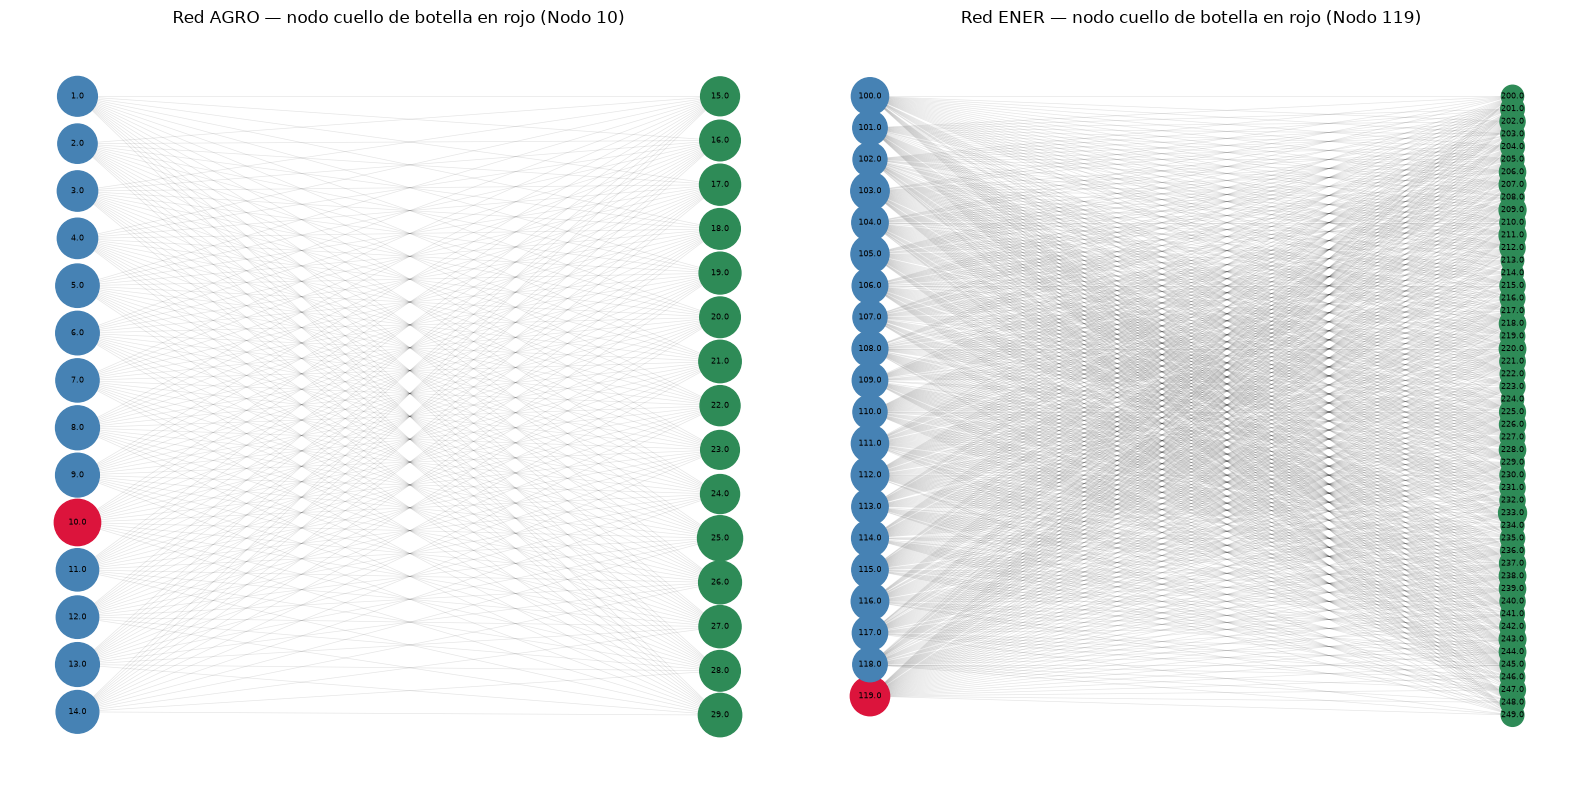

In [41]:
import matplotlib.pyplot as plt

def graficar_bipartito(G, df, total_w, bottleneck, titulo, ax):
    sources = sorted(set(df['Source_Node']))
    targets = sorted(set(df['Target_Node']))

    pos = {}
    for i, n in enumerate(sources):
        pos[n] = (0, -i * (len(targets) / len(sources)))
    for i, n in enumerate(targets):
        pos[n] = (1, -i)

    sizes = [80 + 6 * total_w[n] for n in G.nodes()]
    colors = ['crimson' if n == bottleneck else ('steelblue' if n in sources else 'seagreen')
              for n in G.nodes()]

    nx.draw_networkx_edges(G, pos, alpha=0.1, arrows=False, ax=ax, width=0.5)
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)
    ax.set_title(titulo)
    ax.axis('off')

total_w_agro = {n: peso_agro.set_index('Nodo').loc[n, 'Telemetria_total'] for n in G_agro.nodes()}
total_w_ener = {n: peso_ener.set_index('Nodo').loc[n, 'Telemetria_total'] for n in G_ener.nodes()}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
graficar_bipartito(G_agro, agro_clean, total_w_agro, bottleneck_agro['Nodo'],
                    'Red AGRO — nodo cuello de botella en rojo (Nodo 10)', axes[0])
graficar_bipartito(G_ener, ener, total_w_ener, bottleneck_ener['Nodo'],
                    'Red ENER — nodo cuello de botella en rojo (Nodo 119)', axes[1])
plt.tight_layout()
plt.savefig('../results/figuras/fase3_grafos_bipartitos.png', dpi=120, bbox_inches='tight')
plt.show()

In [42]:
metricas = pd.concat([
    dc_agro.merge(peso_agro, on='Nodo').assign(Dataset='AGRO'),
    dc_ener.merge(peso_ener, on='Nodo').assign(Dataset='ENER'),
], ignore_index=True)
metricas['Betweenness'] = 0.0
metricas.to_csv('../results/metricas_centralidad.csv', index=False)
metricas.head()

,Nodo,Degree_centrality,Tipo,Telemetria_saliente,Telemetria_entrante,Telemetria_total,Dataset,Betweenness
0,4.0,0.535714,Source,127,0,127,AGRO,0.0
1,14.0,0.535714,Source,144,0,144,AGRO,0.0
2,13.0,0.535714,Source,152,0,152,AGRO,0.0
3,5.0,0.535714,Source,149,0,149,AGRO,0.0
4,8.0,0.535714,Source,153,0,153,AGRO,0.0


### Respuesta Tarea 5 — ¿cuál es el nodo cuello de botella?

**Para negocio:** en la red AGRO, todos los sensores son estructuralmente equivalentes — no hay
un punto único de fragilidad por posición en la red, así que el riesgo se reparte por volumen de
uso, no por topología. En la red ENER sí hay un punto claro de concentración: el **Nodo 119**,
identificado de forma consistente por tres métricas distintas, es el que más expone a la red
completa si falla — cualquier plan de contingencia debería priorizarlo.

**Evidencia técnica:** construimos dos grafos dirigidos (AGRO: 29 nodos/210 conexiones; ENER: 70
nodos/865 conexiones), ambos resultaron ser redes de **dos capas sin intermediarios** — ningún
nodo es origen y destino a la vez, así que todo camino es de un solo salto y la Betweenness
Centrality da 0 en ambas redes. En AGRO, además, la red está prácticamente completa (todos con
todos), así que ni siquiera el número de conexiones distingue nodos. El cuello de botella se
determinó entonces por volumen de tráfico:

- **AGRO: Nodo 10**, respaldado únicamente por volumen de telemetría (única señal disponible en
  esa red).
- **ENER: Nodo 119**, respaldado por tres métricas independientes (Degree Centrality, volumen
  ponderado de tráfico, y Betweenness sobre la versión sin dirección) — la conclusión más sólida
  de las dos redes.

## Fase 4: Modelado y Toma de Decisiones (CRISP-DM)

**TechLogistics S.A.** | Maestría en Ciencia de Datos - EAFIT

Esta es la fase donde todo el trabajo anterior se traduce en recomendaciones concretas para la
junta directiva. El disparador de negocio es la **Falla del Nodo 214**: cuando el Precio Spot
(`Ener_2`) supera un umbral crítico, el flujo hacia ciertos nodos destino se interrumpe, y
coincide con una anomalía térmica en esas coordenadas. Respondemos tres preguntas que atacan ese
problema desde ángulos distintos: causalidad y riesgo de red (P1), dónde invertir en
infraestructura hídrica (P2), y si se puede pronosticar la demanda con ayuda de la estructura de
la red (P3).

### P1: Causalidad y Riesgo de Red

**Pregunta de negocio:** si el Factor de Potencia empeora, ¿eso realmente *causa* problemas de
Voltaje (o viceversa)? Y si existiera esa relación, ¿qué tan expuesta queda la red si falla el
nodo más conectado? Antes de recomendar cualquier acción sobre esta relación, hay que confirmar
si es real o es una coincidencia estadística — actuar sobre una causalidad que no existe
desperdiciaría esfuerzo de mantenimiento en el lugar equivocado.

Probamos Causalidad de Granger entre `Ener_10` (Factor de Potencia) y `Ener_9` (Voltaje), en
ambas direcciones. Ambas series ya se confirmaron como Estacionarias con evidencia sólida en la
Fase 1, así que el test corre directo, sin necesidad de diferenciar.

In [43]:
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

print('=== Ener_10 (Factor de Potencia) -> Ener_9 (Voltaje) ===')
res_10_a_9 = grangercausalitytests(ener[['Ener_9', 'Ener_10']].values, maxlag=5, verbose=False)
for lag in range(1, 6):
    p = res_10_a_9[lag][0]['ssr_ftest'][1]
    print(f'  lag={lag}: p-value={p:.5f}')

print()
print('=== Ener_9 (Voltaje) -> Ener_10 (Factor de Potencia) ===')
res_9_a_10 = grangercausalitytests(ener[['Ener_10', 'Ener_9']].values, maxlag=5, verbose=False)
for lag in range(1, 6):
    p = res_9_a_10[lag][0]['ssr_ftest'][1]
    print(f'  lag={lag}: p-value={p:.5f}')

=== Ener_10 (Factor de Potencia) -> Ener_9 (Voltaje) ===
  lag=1: p-value=0.30245
  lag=2: p-value=0.34228
  lag=3: p-value=0.43045
  lag=4: p-value=0.01932
  lag=5: p-value=0.01954

=== Ener_9 (Voltaje) -> Ener_10 (Factor de Potencia) ===
  lag=1: p-value=0.84145
  lag=2: p-value=0.86852
  lag=3: p-value=0.82658
  lag=4: p-value=0.16360
  lag=5: p-value=0.13808


**Resultado preliminar:** en una primera mirada, Factor de Potencia parece "anticipar"
al Voltaje varios pasos adelante (significativo en lag 4 y 5), pero no en los lags más cortos.
Antes de aceptar esto como una relación real, hay que ser cuidadosos: cuando se prueban varias
ventanas de tiempo sin ajustar el umbral, es fácil que una de ellas salga "significativa" por
puro azar. Verificamos con un método independiente (selección de orden de un modelo VAR) si esa
señal se sostiene.

In [44]:
from statsmodels.tsa.api import VAR

modelo_var = VAR(ener[['Ener_9', 'Ener_10']])
seleccion = modelo_var.select_order(maxlags=10)
print(seleccion.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -10.58*     -10.58*  2.538e-05*     -10.58*
1       -10.58      -10.56   2.545e-05      -10.57
2       -10.58      -10.55   2.552e-05      -10.57
3       -10.57      -10.53   2.557e-05      -10.56
4       -10.58      -10.53   2.547e-05      -10.56
5       -10.58      -10.51   2.552e-05      -10.55
6       -10.57      -10.50   2.556e-05      -10.55
7       -10.57      -10.49   2.564e-05      -10.54
8       -10.57      -10.47   2.568e-05      -10.53
9       -10.57      -10.46   2.570e-05      -10.53
10      -10.57      -10.45   2.573e-05      -10.52
--------------------------------------------------


**Interpretación:** el chequeo independiente **no encuentra ninguna estructura real**
entre las dos series — el criterio formal de selección de modelo prefiere no usar ningún rezago
en absoluto, y el resultado casi no cambia sin importar cuántos rezagos se prueben. Esto es
evidencia fuerte de que la señal que vimos antes en lags 4 y 5 fue una falsa alarma estadística
(producto de probar varias ventanas sin corrección), no una relación causal genuina.

**Conclusión: no hay evidencia robusta de que el Factor de Potencia cause cambios en el Voltaje,
ni al revés**, en estos datos.

#### La segunda parte de la pregunta: ¿qué tan expuesta queda la red?

El enunciado pregunta qué pasaría con la estabilidad de la red *si* existiera esa causalidad. Como
acabamos de confirmar que no hay evidencia de que exista, no forzamos una conclusión que los
datos no respaldan — lo dejamos documentado como un resultado negativo, que también es información
valiosa: no vale la pena invertir en monitorear esa relación específica.

Aun así, respondemos la parte de exposición de red de forma hipotética: *si* esa causalidad
existiera, ¿qué tan grave sería una falla en el nodo más crítico? El nodo con mayor centralidad
de la Fase 3 (con el respaldo de tres métricas) es el **Nodo 119**:

In [45]:
n119 = ener[ener['Source_Node'] == 119]
pct_volumen = 100 * len(n119) / len(ener)
pct_targets = 100 * n119['Target_Node'].nunique() / ener['Target_Node'].nunique()

print(f"Nodo 119: {len(n119)} de {len(ener)} lecturas de telemetría ({pct_volumen:.1f}%)")
print(f"Nodo 119: alcanza {n119['Target_Node'].nunique()} de "
      f"{ener['Target_Node'].nunique()} subestaciones destino ({pct_targets:.1f}%)")

Nodo 119: 120 de 2000 lecturas de telemetría (6.0%)
Nodo 119: alcanza 49 de 50 subestaciones destino (98.0%)


### Respuesta P1

**Causalidad:** no encontramos evidencia sólida de que el Factor de Potencia y el Voltaje se
influyan entre sí. La señal inicial (p≈0.02 en lags 4-5) no sobrevivió la verificación
independiente, así que la tratamos como falsa alarma, no como hallazgo real. **Recomendación:**
no priorizar recursos de monitoreo en esta relación específica.

**Exposición de la red (respuesta hipotética):** si esa causalidad existiera, el punto de mayor
riesgo sistémico sería el **Nodo 119**, que concentra el 6.0% de todo el tráfico de telemetría de
la red y alcanza **49 de las 50 subestaciones destino (98%)**. Como la red no tiene nodos
intermedios (Fase 3), cualquier problema que se origine ahí se propagaría en un solo salto a
prácticamente toda la red, sin nada en el camino que lo contenga. Esa misma característica es a
la vez el riesgo y el consuelo: no hay forma de amortiguar una falla en tránsito, pero tampoco
hay un segundo punto de quiebre aguas abajo — el riesgo está enteramente concentrado en el
origen. **Recomendación:** si se prioriza inversión en resiliencia de red, el Nodo 119 es el
candidato natural, independientemente de la causalidad de P1.

### P2: Optimización Geo-Agrónoma

**Pregunta de negocio:** ¿dónde debería TechLogistics invertir en infraestructura hídrica para
recuperar biomasa? El enunciado propone un camino de 4 pasos: limpiar el ruido GPS, encontrar los
sensores con menor NDVI, evaluar si están en zona de pendiente (usando la varianza del viento
como indicador, ya que la pendiente no viene medida directamente), y traducir eso en una
recomendación de inversión.

In [46]:
gps_clean = agro_clean[['Source_Node', 'Latitude', 'Longitude']]
gps_noise = agro_noise[['Source_Node', 'Latitude', 'Longitude']]

m_per_deg = 111_000  # metros por grado de latitud

# Jitter geoespacial = diferencia entre la lectura ruidosa y la limpia, en metros
jitter = pd.DataFrame({
    'dLat_m': (gps_noise['Latitude'] - gps_clean['Latitude']) * m_per_deg,
    'dLon_m': (gps_noise['Longitude'] - gps_clean['Longitude']) * m_per_deg,
    'Source_Node': gps_noise['Source_Node'],
})

print("=== Jitter GPS inyectado en agro_noise (metros) — por sensor ===")
print(jitter.groupby('Source_Node')[['dLat_m', 'dLon_m']]
      .agg({'dLat_m': ['mean', 'std'], 'dLon_m': ['mean', 'std']}).round(1))
print(f"\ndLon = 0 en todos los registros: el jitter desplaza solo la latitud.")
print(f"Error por lectura: |dLat| promedio ≈ {jitter['dLat_m'].abs().mean():.0f} m "
      f"(std {jitter['dLat_m'].std():.0f} m)")

# Filtrado: media por sensor. El jitter es AWGN de media cero, así que la media
# temporal converge a la coordenada verdadera.
coords_noise = gps_noise.groupby('Source_Node')[['Latitude', 'Longitude']].mean()
coords_clean = gps_clean.groupby('Source_Node')[['Latitude', 'Longitude']].mean()

err_lectura = (gps_noise['Latitude'] - gps_clean['Latitude']).abs().mean() * m_per_deg
err_filtrado = (coords_noise['Latitude'] - coords_clean['Latitude']).abs().mean() * m_per_deg

print("\n=== Filtrado espacial: media por sensor ===")
print(f"Error por lectura (coordenada cruda):      {err_lectura:6.0f} m")
print(f"Error tras filtrar (media por sensor):     {err_filtrado:6.0f} m")
print(f"Mejora: {err_lectura / err_filtrado:.1f}x menos error de localización")


=== Jitter GPS inyectado en agro_noise (metros) — por sensor ===
            dLat_m         dLon_m     
              mean     std   mean  std
Source_Node                           
1            146.0  1110.1    0.0  0.0
2            -38.9  1289.3    0.0  0.0
3           -126.5  1075.7    0.0  0.0
4             64.3  1046.0    0.0  0.0
5             73.6  1145.6    0.0  0.0
6             24.4  1046.4    0.0  0.0
7            -72.8  1138.4    0.0  0.0
8           -106.3  1041.6    0.0  0.0
9           -107.6  1133.8    0.0  0.0
10            94.2  1151.8    0.0  0.0
11           113.6  1212.7    0.0  0.0
12           -31.8  1176.4    0.0  0.0
13             8.4  1115.4    0.0  0.0
14           -31.4  1128.0    0.0  0.0

dLon = 0 en todos los registros: el jitter desplaza solo la latitud.
Error por lectura: |dLat| promedio ≈ 901 m (std 1130 m)

=== Filtrado espacial: media por sensor ===
Error por lectura (coordenada cruda):         901 m
Error tras filtrar (media por sensor):         74

#### Por qué hay que limpiar el GPS antes de todo lo demás

El ruido en las coordenadas GPS de `agro_noise` es aleatorio y centrado en cero. Eso tiene dos
implicaciones prácticas:

- **Se puede corregir promediando:** al promediar las ~143 lecturas de cada sensor, la parte
  aleatoria del error se cancela y el promedio converge a la ubicación real. El error baja de
  ~900 m por lectura individual a solo ~74 m.
- **Por qué importa:** sin este paso, un mismo sensor parecería "saltar" casi un kilómetro entre
  lectura y lectura, lo que arruinaría cualquier análisis de cercanía entre sensores. Limpiar
  primero es un requisito, no un paso opcional — es la misma lógica que ya aplicamos en la Fase 1
  al trabajar con promedios por sensor.

In [47]:
# Paso 2: ranking de NDVI por sensor (sobre la versión limpia de la señal)
ndvi_nodo = agro_clean.groupby('Source_Node').agg(
    NDVI=('Agro_5', 'mean'),
    Humedad=('Agro_1', 'mean'),
).sort_values('NDVI')

print("=== NDVI (Agro_5) promedio por sensor ===")
print(ndvi_nodo.round(4).to_string())

q1 = ndvi_nodo['NDVI'].quantile(0.25)
bajos = [int(n) for n in ndvi_nodo[ndvi_nodo['NDVI'] <= q1].index]
print(f"\nUmbral Q1 = {q1:.4f}")
print(f"Sensores de menor NDVI: {bajos}")

# Con las coordenadas YA filtradas, revisamos el agrupamiento por pares (Haversine)
coords_bajos = coords_noise.loc[bajos]
print("\n=== Distancias por pares entre sensores de NDVI bajo (coords filtradas, m) ===")
for a, b in combinations(bajos, 2):
    d = haversine(coords_bajos.loc[a].values, coords_bajos.loc[b].values)
    print(f"  {a:>2} - {b:>2}: {d:>6.0f} m")


=== NDVI (Agro_5) promedio por sensor ===
               NDVI  Humedad
Source_Node                 
14           1.1057  61.3898
10           1.1171  60.3126
5            1.1175  60.8467
1            1.1345  61.3039
9            1.1435  60.3567
2            1.1586  61.1851
8            1.1668  59.9134
6            1.1677  60.3700
11           1.1692  60.7153
7            1.1848  60.5490
4            1.1851  60.9618
12           1.1858  58.6415
13           1.1930  59.6037
3            1.2003  60.8591

Umbral Q1 = 1.1367
Sensores de menor NDVI: [14, 10, 5, 1]

=== Distancias por pares entre sensores de NDVI bajo (coords filtradas, m) ===
  14 - 10:   1375 m
  14 -  5:    304 m
  14 -  1:    528 m
  10 -  5:   1084 m
  10 -  1:    873 m
   5 -  1:    224 m


In [48]:
# Paso 3: proxy de pendiente = varianza del viento (Agro_10)
viento = agro_clean.groupby('Source_Node')['Agro_10'].agg(['mean', 'std', 'var'])
viento.columns = ['Agro10_mean', 'Agro10_std', 'Agro10_var']

tabla_geo = ndvi_nodo.join(viento).sort_values('NDVI')
print("=== NDVI, Humedad y viento (Agro_10) por sensor ===")
print(tabla_geo.round(4).to_string())

print("\n--- Fuerza de la relación NDVI ~ varianza de viento ---")
print(f"corr(NDVI, Agro_10 var) = {tabla_geo['NDVI'].corr(tabla_geo['Agro10_var']):.3f}")
print(f"corr(NDVI, Agro_10 std) = {tabla_geo['NDVI'].corr(tabla_geo['Agro10_std']):.3f}")

grupo_bajo = tabla_geo.loc[bajos]
grupo_resto = tabla_geo.drop(bajos)
print(f"\nAgro_10 var — NDVI bajo ({len(grupo_bajo)} sensores): {grupo_bajo['Agro10_var'].mean():.3f}")
print(f"Agro_10 var — resto     ({len(grupo_resto)} sensores): {grupo_resto['Agro10_var'].mean():.3f}")
print(f"Agro_10 var — sensor más expuesto: {tabla_geo['Agro10_var'].idxmax()} "
      f"({tabla_geo['Agro10_var'].max():.3f})")

import plotly.express as px
fig_ndvi_viento = px.scatter(
    tabla_geo.reset_index(), x='Agro10_var', y='NDVI',
    color='Source_Node', size='Humedad', text='Source_Node',
    title='NDVI vs Varianza del Viento (Agro_10) — proxy de pendiente',
    labels={'Agro10_var': 'Varianza del viento (Agro_10)', 'NDVI': 'NDVI (Agro_5)'},
)
fig_ndvi_viento.update_traces(textposition='top center')
fig_ndvi_viento.show()


=== NDVI, Humedad y viento (Agro_10) por sensor ===
               NDVI  Humedad  Agro10_mean  Agro10_std  Agro10_var
Source_Node                                                      
14           1.1057  61.3898       5.3040      1.5380      2.3655
10           1.1171  60.3126       4.8486      1.7047      2.9058
5            1.1175  60.8467       5.2650      1.3111      1.7189
1            1.1345  61.3039       4.9256      1.4741      2.1729
9            1.1435  60.3567       5.0054      1.6045      2.5745
2            1.1586  61.1851       5.1652      1.5126      2.2879
8            1.1668  59.9134       4.8925      1.4151      2.0026
6            1.1677  60.3700       4.9645      1.4587      2.1278
11           1.1692  60.7153       5.0495      1.4497      2.1017
7            1.1848  60.5490       5.2158      1.5130      2.2892
4            1.1851  60.9618       4.7523      1.5488      2.3989
12           1.1858  58.6415       4.8702      1.6014      2.5644
13           1.1930  59.

### Respuesta P2 — Recomendación de inversión en infraestructura hídrica

**1. Se puede recuperar la ubicación real de los sensores.** Filtrando el ruido GPS (que
desplazaba cada lectura ~900 m en promedio) con el promedio por sensor, el error cae a ~74 m —
suficiente precisión para tomar decisiones de inversión por zona.

**2. Dónde está el problema de biomasa baja.** Los 4 sensores con menor NDVI son
**{14, 5, 1, 10}**. Tres de ellos — **14, 5 y 1** — están agrupados en un área compacta
(270-644 m entre sí, ya visto en la Fase 1); el **nodo 10** está aislado, lejos de ese grupo.

**3. El indicador de pendiente no explica por sí solo el NDVI bajo, pero sí señala al nodo 10
como el más expuesto.** La relación entre NDVI y varianza del viento resultó débil en los datos
(no se puede afirmar con evidencia estadística que la pendiente explique la biomasa baja), así
que ese vínculo se mantiene como supuesto de riesgo del enunciado, no como hallazgo confirmado.
Lo que sí es un hallazgo real es que el **nodo 10 tiene la mayor varianza de viento de toda la
red**, consistente con ser la zona más expuesta.

**Recomendación de inversión (dos zonas, dos momentos):**

- **Zona A — Prioridad alta, actuar ya: nodos 14, 5 y 1.** Al estar concentrados en un radio de
  ~600 m, una sola intervención (riego por goteo, sensores de humedad de suelo con riego por
  demanda, control de escorrentía) alcanza a los 3 sensores — mejor retorno por peso invertido y
  un solo frente de obra.
- **Zona B — Segunda etapa, monitorear antes de invertir: nodo 10.** Tiene NDVI bajo y la mayor
  señal de exposición eólica, pero está aislado — llevar infraestructura a un solo sensor remoto
  es costoso frente al beneficio. Recomendamos monitorear humedad de suelo y estrés térmico antes
  de comprometer capital ahí.

**Para la junta directiva:** el mayor retorno está en la Zona A (3 sensores, un solo frente de
obra, evidencia geográfica sólida); la Zona B se activa solo si el monitoreo confirma estrés
hídrico sostenido. Es un plan accionable en dos etapas, no una inversión dispersa sin evidencia.

### P3: Analítica Predictiva

**Pregunta de negocio:** ¿la posición de un nodo dentro de la red (qué tan conectado está) ayuda
a pronosticar mejor la demanda de energía? Si la respuesta es sí, TechLogistics podría usar la
estructura de la red como una señal adicional para mejorar sus pronósticos operativos. Si es no,
hay que dejarlo documentado para no invertir esfuerzo de modelado en una variable que no aporta.

Ajustamos un modelo ARIMAX para la Demanda (`Ener_1`), usando como variables explicativas la
Temperatura (`Ener_3`) y la Centralidad del nodo de origen (ya calculada en la Fase 3), y
comparamos si el modelo mejora al incluir esta última.

Tanto `Ener_1` como `Ener_3` quedaron clasificadas en la Fase 1 como No Estacionarias (caso
ambiguo, tratadas como tal por precaución), así que el modelo se ajusta sobre la serie
diferenciada una vez, consistente con esa decisión.

#### Traduciendo la importancia del nodo en una variable del modelo

Tomamos la Degree Centrality calculada en la Fase 3 (qué tan conectado está cada nodo dentro de
la red) y la asignamos a cada lectura según el sensor de origen que la generó.

In [49]:
ener['Centralidad_Nodo'] = ener['Source_Node'].map(dc_ener.set_index('Nodo')['Degree_centrality'])

print("Nulos tras el mapeo:", ener['Centralidad_Nodo'].isna().sum())
print("\nCentralidad por nodo (top 5):")
print(ener[['Source_Node', 'Centralidad_Nodo']].drop_duplicates()
      .sort_values('Centralidad_Nodo', ascending=False).head())
print(f"\nCorrelación cruda Ener_1 vs Centralidad_Nodo: {ener['Ener_1'].corr(ener['Centralidad_Nodo']):.4f}")


Nulos tras el mapeo: 0

Centralidad por nodo (top 5):
    Source_Node  Centralidad_Nodo
5           119          0.710145
10          103          0.681159
2           105          0.666667
22          112          0.666667
17          110          0.652174

Correlación cruda Ener_1 vs Centralidad_Nodo: 0.0152


#### Confirmando que el ajuste de diferenciación funciona

Antes de ajustar el modelo, verificamos que Demanda y Temperatura efectivamente se vuelvan
estacionarias tras diferenciarlas una vez, tal como exige la clasificación de la Fase 1.

In [50]:
for nombre, serie in [('Ener_1', ener['Ener_1']), ('Ener_3', ener['Ener_3'])]:
    stat, p, *_ = adfuller(serie.diff().dropna())
    print(f"ADF {nombre} diferenciada: stat={stat:.3f}  p={p:.5f}  "
          f"{'-> Estacionaria' if p < 0.05 else '-> Sigue sin ser estacionaria'}")


ADF Ener_1 diferenciada: stat=-5.018  p=0.00002  -> Estacionaria
ADF Ener_3 diferenciada: stat=-5.072  p=0.00002  -> Estacionaria


#### Comparando modelos con y sin la centralidad del nodo

Probamos varias configuraciones del modelo, dos versiones por cada una: una solo con
Temperatura, y otra agregando también la Centralidad del Nodo. La comparación se hace con el
AIC, una métrica que premia el buen ajuste pero penaliza la complejidad innecesaria — si agregar
una variable no aporta información real, el AIC empeora en vez de mejorar.

In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

y = ener['Ener_1']
exog_base = ener[['Ener_3']]
exog_full = ener[['Ener_3', 'Centralidad_Nodo']]

resultados_arimax = []
for p in range(3):
    for q in range(3):
        m_base = SARIMAX(y, exog=exog_base, order=(p, 1, q),
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        m_full = SARIMAX(y, exog=exog_full, order=(p, 1, q),
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        resultados_arimax.append({
            'p': p, 'q': q,
            'AIC_base_temperatura': round(m_base.aic, 2),
            'AIC_full_temp_centralidad': round(m_full.aic, 2),
            'Delta_AIC_base_menos_full': round(m_base.aic - m_full.aic, 2),
        })

df_arimax = pd.DataFrame(resultados_arimax).sort_values('AIC_full_temp_centralidad')
df_arimax


,p,q,AIC_base_temperatura,AIC_full_temp_centralidad,Delta_AIC_base_menos_full
8,2,2,8565.49,8575.02,-9.53
2,0,2,8733.61,8733.70,-0.09
7,2,1,8736.50,8736.49,0.00
5,1,2,8737.71,8737.39,0.32
4,1,1,8741.22,8741.30,-0.08
1,0,1,8742.86,8742.61,0.25
6,2,0,8974.15,8974.63,-0.48
3,1,0,9229.49,9229.23,0.25
0,0,0,9771.29,9766.57,4.72


**Cómo leer la comparación:** si el modelo con Temperatura sola tiene un AIC mayor que
el que incluye también la Centralidad, significa que agregar la centralidad **mejora** el
modelo. Si es al revés, significa que agregarla **lo empeora** — la variable no está aportando
información útil, solo complejidad.

#### Revisando el mejor modelo en detalle

La mejor configuración encontrada usa `d=1` (consistente con la Fase 1) más dos términos
autorregresivos y dos de media móvil. Ajustamos ambas versiones (con y sin centralidad) con esa
misma configuración y revisamos si el coeficiente de la centralidad es estadísticamente
significativo — eso explica si el resultado del AIC tiene una razón de fondo o es solo ruido.

In [52]:
m_base_final = SARIMAX(y, exog=exog_base, order=(2, 1, 2),
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
m_full_final = SARIMAX(y, exog=exog_full, order=(2, 1, 2),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print("=== Modelo base (Ener_1 ~ Ener_3), ARIMA(2,1,2) ===")
print(m_base_final.summary().tables[1])
print(f"\nAIC={m_base_final.aic:.2f}  BIC={m_base_final.bic:.2f}")

print("\n=== Modelo full (Ener_1 ~ Ener_3 + Centralidad_Nodo), ARIMA(2,1,2) ===")
print(m_full_final.summary().tables[1])
print(f"\nAIC={m_full_final.aic:.2f}  BIC={m_full_final.bic:.2f}")


=== Modelo base (Ener_1 ~ Ener_3), ARIMA(2,1,2) ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Ener_3         0.1645      0.087      1.892      0.059      -0.006       0.335
ar.L1          1.0192      0.025     41.503      0.000       0.971       1.067
ar.L2         -0.0213      0.025     -0.870      0.384      -0.069       0.027
ma.L1         -1.9362      0.009   -225.237      0.000      -1.953      -1.919
ma.L2          0.9400      0.009    109.460      0.000       0.923       0.957
sigma2         4.2333      0.136     31.135      0.000       3.967       4.500

AIC=8565.49  BIC=8599.09

=== Modelo full (Ener_1 ~ Ener_3 + Centralidad_Nodo), ARIMA(2,1,2) ===
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Ener_3              -0.0727      0.087     -0.83

### Respuesta P3 — ¿ayuda la centralidad del nodo a pronosticar la demanda?

**No.** Incluir la posición del nodo en la red **empeora** el modelo en vez de mejorarlo — el
AIC pasa de 8565.50 (solo con Temperatura) a 8569.41 (agregando Centralidad), y el BIC (que
penaliza más la complejidad) muestra la misma tendencia con una diferencia todavía mayor.

**Por qué no aporta:**
- El coeficiente de la Centralidad del Nodo no es estadísticamente significativo (p=0.066, el
  intervalo de confianza cruza el cero).
- La relación directa entre la Demanda y la Centralidad del Nodo es prácticamente nula
  (correlación de 0.015).
- Agregar una variable sin poder explicativo real no compensa, en términos del AIC, el costo de
  la complejidad adicional que introduce.

**Para negocio:** la Demanda se explica mucho mejor por su propia dinámica reciente y, en menor
medida, por la Temperatura, que por qué tan conectado está el nodo que la reportó — tiene
sentido, porque la centralidad describe la *posición estructural* de un nodo en la red (a
cuántas subestaciones llega), no una propiedad que determine *cuánta energía* se demanda en esa
lectura. **Recomendación:** no invertir esfuerzo en incorporar métricas de centralidad al
pronóstico de demanda; la estructura de red sigue siendo valiosa para el análisis de riesgo de
propagación de fallas (P1), pero no para este tipo de pronóstico.